In [2]:
import numpy as np
import matplotlib.pyplot as plt
from Data import DataManager as DM

2025-09-19 19:19:46.166654: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-19 19:19:46.227043: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-09-19 19:19:46.281559: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758302386.332450  223526 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758302386.353000  223526 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1758302386.454765  223526 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

In [3]:
# Filter images of the selected digit
images = DM().get_images_by_digit(1)

In [4]:
images.shape

(6742, 28, 28)

In [5]:
images.shape[0]

6742

In [6]:
if images.shape[0] >= 16:
    idx = np.random.choice(images.shape[0], 16, replace=False)
    selected_images = images[idx]
else:
    selected_images = images

In [7]:
D = DM()
Images = D.get_images_by_digit(1)

In [8]:
a,b = D.POD(Images,10)

In [9]:
a.shape

(28, 28, 10)

In [10]:
b.shape

(28, 28)

In [11]:
a_reshaped = a.reshape(28, 28, -1)

In [12]:
a_reshaped.shape

(28, 28, 10)

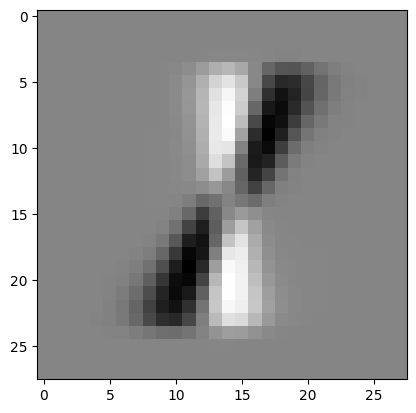

In [13]:
plt.imshow(a_reshaped[:,:,0],cmap='gray')

In [14]:
b,e = D.eigenvector_basis(Images[0],Images[0].shape[0])

In [15]:
number_of_modes = 10

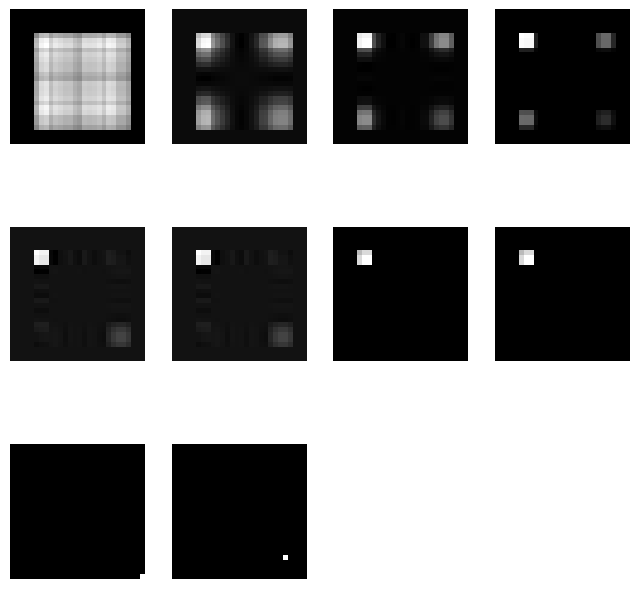

In [16]:
fig4, axes4 = plt.subplots(number_of_modes // 4 + 1, 4, figsize=(8, 8))
for i, ax in enumerate(axes4.flatten()):
    if i < number_of_modes:
        ax.imshow(np.real(b[i]), cmap='gray')
        ax.axis('off')
    else:
        ax.axis('off')
plt.show(fig4)

In [17]:
n=Images[0].shape[0]
reconstructed_image = D.reconstruct_image(b, e, n)


In [18]:
b.shape

(28, 28, 28)

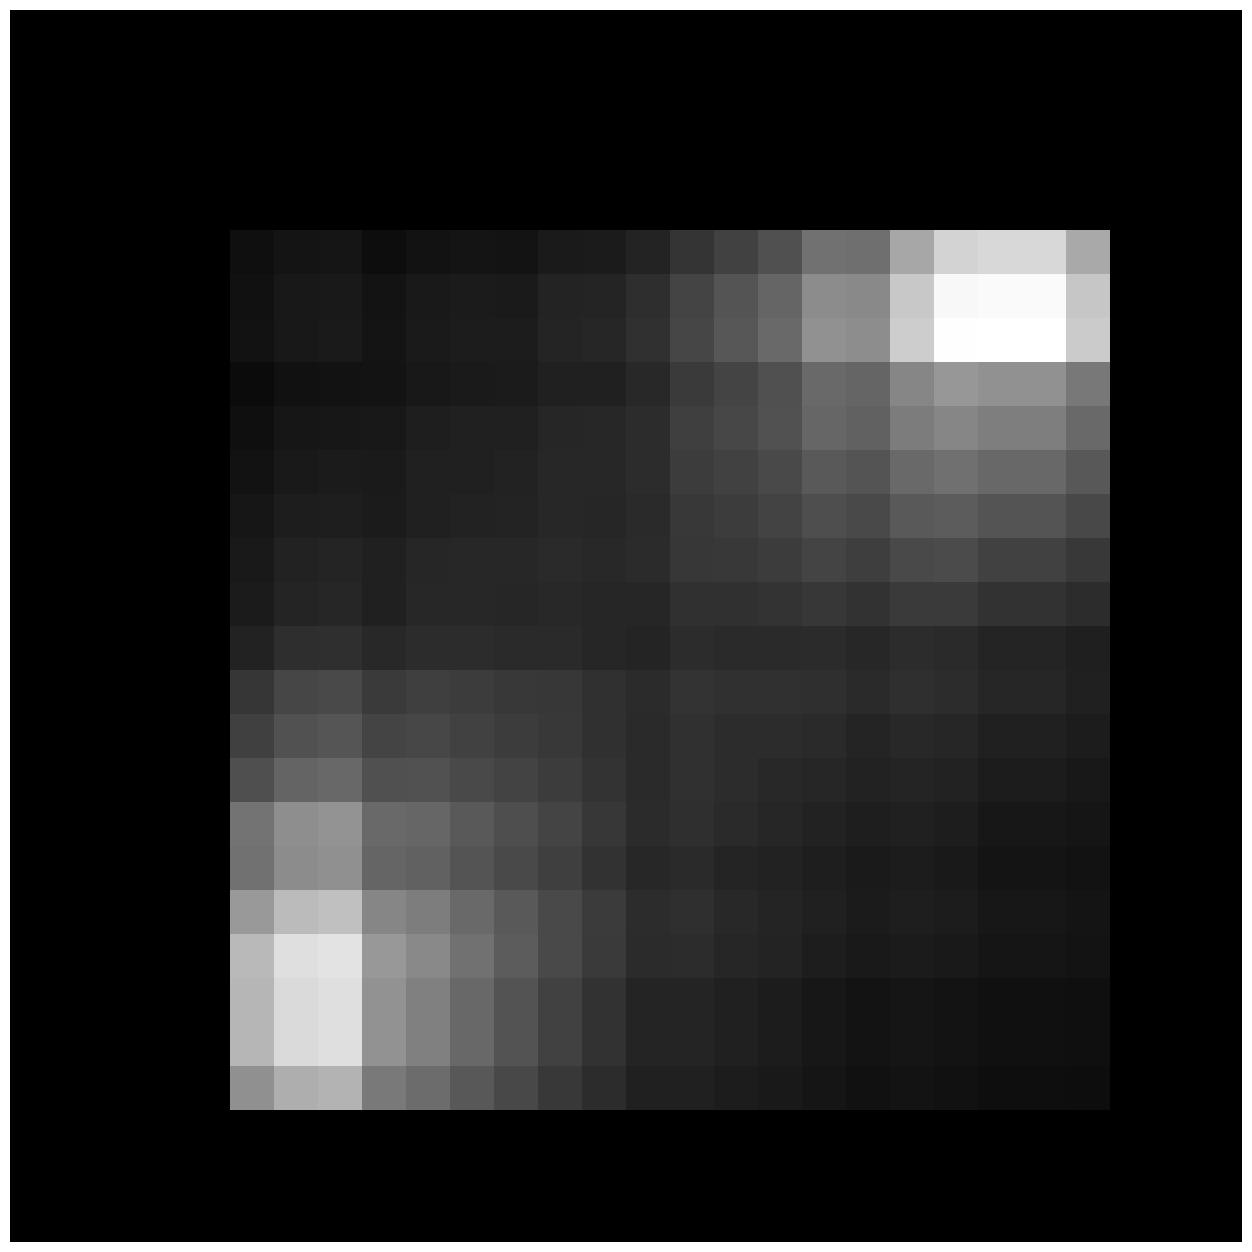

In [19]:
fig5, axes5 = plt.subplots(figsize=(16, 16))
axes5.imshow(reconstructed_image, cmap='gray')
axes5.axis('off')
plt.show(fig5)

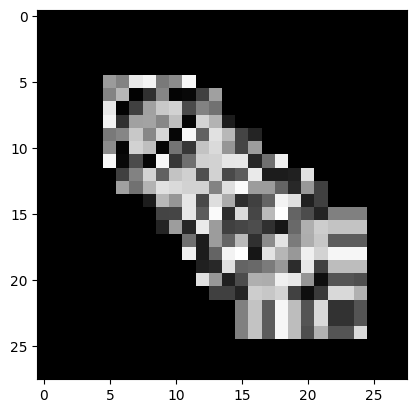

In [20]:
Img = Images[0].copy()
Img = Img@Img.T
plt.imshow(Img,cmap='gray')

In [21]:
b,e = D.eigenvector_basis(Img,Img.shape[0])

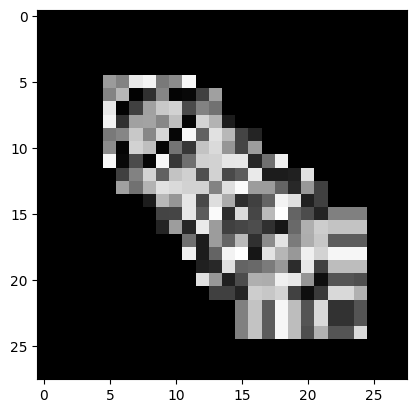

In [22]:
RI = D.reconstruct_image(b,e,Img.shape[0])
plt.imshow(RI,cmap='gray')

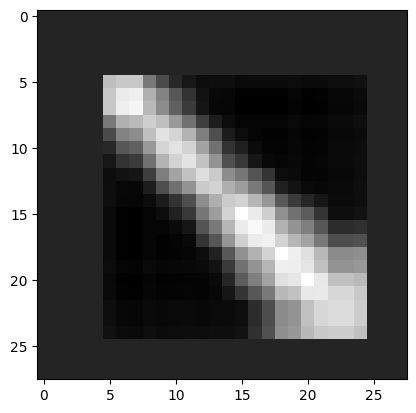

In [23]:
Img2 = np.cov(Images[0])
b2,e2 = D.eigenvector_basis(Img2,Img2.shape[0])
RI2 = D.reconstruct_image(b2,e2,Img2.shape[0])
plt.imshow(Img2,cmap='gray')

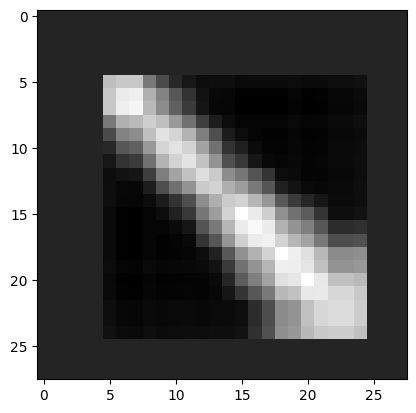

In [24]:
plt.imshow(RI2,cmap='gray')

In [25]:
np.allclose(RI2,RI2.T)

True

In [26]:
from scipy.linalg import expm


In [27]:
ImgO = expm(1j*np.cov(Images[0]))
ImgC = np.cov(Images[0])


In [28]:
EigenBasisO, EigenValuesO = D.eigenvector_basis(ImgO, ImgO.shape[0])
EigenBasisC, EigenValuesC = D.eigenvector_basis(ImgC, ImgC.shape[0])



In [29]:
np.allclose(EigenBasisO,EigenBasisC)

False

In [30]:
from pandas import DataFrame as df

In [31]:
EigenValuesO_df = df(EigenValuesO, columns=['EigenvaluesO'])
EigenValuesC_df = df(EigenValuesC, columns=['EigenvaluesC'])

In [32]:
display(EigenValuesO_df)

,EigenvaluesO
0,1.000000-0.000000j
1,1.000000-0.000000j
2,1.000000-0.000000j
3,1.000000+0.000000j
4,1.000000+0.000000j
5,1.000000+0.000000j
6,1.000000+0.000000j
7,1.000000+0.000000j
8,1.000000+0.000000j
9,1.000000+0.000000j


In [33]:
display(EigenValuesC_df)

,EigenvaluesC
0,4.384356e+04
1,2.808684e+04
2,2.277505e+04
3,1.562358e+04
4,6.024584e+03
5,2.211988e+03
6,8.287044e+02
7,7.241804e+02
8,4.624031e+02
9,2.735203e+02


In [34]:
np.allclose(ImgO@ImgO.conj().T,np.eye(ImgO.shape[0]))

True

In [35]:
MatTmp =ImgO@ImgO.conj().T
MatTmp_df = df(np.real(MatTmp))
display(MatTmp_df)

,0,1,2,3,4,5,6,7,8,9,...,18,19,20,21,22,23,24,25,26,27
0,1.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,1.000000e+00,-1.461956e-13,-1.301108e-12,-3.557212e-13,-1.212787e-13,...,1.940815e-13,-2.211555e-13,4.341754e-14,2.391289e-13,-2.827070e-14,1.840531e-13,-2.096232e-13,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,-1.461956e-13,1.000000e+00,4.887980e-13,-4.179287e-13,-1.117213e-13,...,-4.971512e-13,2.625419e-13,-1.859887e-13,-9.156888e-14,8.388969e-14,-5.607118e-14,5.432790e-13,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,-1.301108e-12,4.887980e-13,1.000000e+00,-4.635957e-13,1.756662e-14,...,-1.414931e-13,-1.059345e-13,9.878674e-14,-5.518703e-14,1.642175e-13,8.463428e-14,-6.023332e-14,0.0,0.0,0.0
8,0.0,0.0,0.0,0.0,0.0,-3.557212e-13,-4.179287e-13,-4.635957e-13,1.000000e+00,-2.504947e-13,...,-2.085467e-13,-4.966308e-13,-2.492543e-13,-1.129931e-13,1.794214e-13,2.362102e-13,1.035696e-13,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,-1.212787e-13,-1.117213e-13,1.756662e-14,-2.504947e-13,1.000000e+00,...,-6.565154e-14,-3.897614e-13,-9.695388e-14,2.192303e-13,5.160407e-14,-6.287281e-14,-3.281469e-13,0.0,0.0,0.0


In [36]:
Image = (Images[0]+1) / 256.0  # Avoiding division by zero and normalizing
Image = Image @ Image.T  
U = expm(1j * Image)
np.allclose(U @ U.conj().T, np.eye(len(Image)), atol=1e-5)

True

In [37]:
Image = (Images[0]+1) / 256.0  # Avoiding division by zero and normalizing
Image = np.cov(Image)  
U = expm(1j * Image)
np.allclose(U @ U.conj().T, np.eye(len(Image)), atol=1e-5)

True

In [38]:
ImgO = (Images[0]+1)/256.0
ImgO = expm(1j*np.cov(ImgO))

ebO, egO = D.eigenvector_basis(ImgO, ImgO.shape[0])


In [39]:
ImgC = (Images[0]+1)/256.0
ImgC = np.cov(ImgC)
ebC, egC = D.eigenvector_basis(ImgC, ImgC.shape[0])


In [40]:
H = np.array([[1, 1], [1, -1]])
eg, eb = np.linalg.eig(H)

In [41]:
eb

array([[ 0.92387953, -0.38268343],
       [ 0.38268343,  0.92387953]])

In [42]:
1/(np.sqrt((1-np.sqrt(2))**2+1))

np.float64(0.9238795325112867)

In [43]:
1/(np.sqrt((1+np.sqrt(2))**2+1))

np.float64(0.3826834323650898)

In [44]:
Tmp = expm(1j*H)
egO, ebO = np.linalg.eig(Tmp)
egO

array([0.15594369+0.98776595j, 0.15594369-0.98776595j])

In [45]:
ebO

array([[ 0.92387953+0.00000000e+00j, -0.38268343+5.55111512e-17j],
       [ 0.38268343+0.00000000e+00j,  0.92387953+0.00000000e+00j]])

In [46]:
eg

array([ 1.41421356, -1.41421356])

In [47]:
np.sqrt(2)

np.float64(1.4142135623730951)

In [48]:
A = np.random.randint(1,5,size=(3,3))

In [49]:
#S= A*A.T
S = np.cov(A)

In [50]:
l1,q1 = np.linalg.eig(S)

In [51]:
q1

array([[-0.8051731 , -0.57735027,  0.13550992],
       [-0.51994159,  0.57735027, -0.6295454 ],
       [-0.28523152,  0.57735027,  0.76505532]])

In [52]:
l2,q2 = np.linalg.eig(1j*expm(S))
np.real(q2)

array([[ 0.8051731 , -0.57735027,  0.13550992],
       [ 0.51994159,  0.57735027, -0.6295454 ],
       [ 0.28523152,  0.57735027,  0.76505532]])

In [53]:
l1

array([ 3.59716754e+00, -1.02624686e-17,  6.94991260e-02])

In [54]:
l2

array([ 0.00000000e+00+36.49471811j, -6.66133808e-16 +1.j        ,
       -1.51246194e-17 +1.07197112j])

In [55]:
n = 4
AImg = np.random.randint(1,100, size=(n,n))
AS = np.cov(AImg)
AU = expm(1j*AS)
ls,qs = np.linalg.eig(AS)
lu,qu = np.linalg.eig(AU)

qs = np.abs(qs)
qu = np.abs(qu)

np.allclose(qs,qu)

False

In [56]:
qs

array([[0.29967863, 0.66857984, 0.64311557, 0.22270179],
       [0.78753284, 0.54008781, 0.24993592, 0.16009131],
       [0.23741191, 0.44857351, 0.29685916, 0.8088832 ],
       [0.48334287, 0.24512847, 0.66015835, 0.52007947]])

In [57]:
qu

array([[0.66857984, 0.29967863, 0.64311557, 0.22270179],
       [0.54008781, 0.78753284, 0.24993592, 0.16009131],
       [0.44857351, 0.23741191, 0.29685916, 0.8088832 ],
       [0.24512847, 0.48334287, 0.66015835, 0.52007947]])

In [58]:
ls

array([ 2.42599094e+03,  1.17714005e+03,  2.39035673e+02, -1.04044709e-13])

In [59]:
sorted_indicess = np.argsort(ls)[::-1]
sorted_indicess

array([0, 1, 2, 3])

In [60]:
sorted_indicesu = np.argsort(np.real(lu))[::-1]
sorted_indicesu

array([3, 2, 1, 0])

In [61]:
sorted_indicesu = np.argsort(np.imag(lu))[::-1]
sorted_indicesu

array([0, 1, 2, 3])

In [62]:
np.argsort(np.angle(lu))[::-1]

array([0, 1, 2, 3])

In [63]:
la = np.angle(lu)
print(la)
for i in range(len(la)):
    if la[i] < 0:
        la[i] = la[i] + 2*np.pi
print(la)
print(np.argsort(la)[::-1])

[2.18439951e+00 6.81413464e-01 2.74631010e-01 6.08950772e-14]
[2.18439951e+00 6.81413464e-01 2.74631010e-01 6.08950772e-14]
[0 1 2 3]


In [64]:
result = np.all(np.isin(qs, qu))
result

np.False_

In [65]:
qst = qs[:,sorted_indicess]
qut = qu[:,sorted_indicess]

In [66]:
qs

array([[0.29967863, 0.66857984, 0.64311557, 0.22270179],
       [0.78753284, 0.54008781, 0.24993592, 0.16009131],
       [0.23741191, 0.44857351, 0.29685916, 0.8088832 ],
       [0.48334287, 0.24512847, 0.66015835, 0.52007947]])

In [67]:
qst

array([[0.29967863, 0.66857984, 0.64311557, 0.22270179],
       [0.78753284, 0.54008781, 0.24993592, 0.16009131],
       [0.23741191, 0.44857351, 0.29685916, 0.8088832 ],
       [0.48334287, 0.24512847, 0.66015835, 0.52007947]])

In [68]:
qu #1,0,3,2
   #1,0,2,3

array([[0.66857984, 0.29967863, 0.64311557, 0.22270179],
       [0.54008781, 0.78753284, 0.24993592, 0.16009131],
       [0.44857351, 0.23741191, 0.29685916, 0.8088832 ],
       [0.24512847, 0.48334287, 0.66015835, 0.52007947]])

In [69]:
qut

array([[0.66857984, 0.29967863, 0.64311557, 0.22270179],
       [0.54008781, 0.78753284, 0.24993592, 0.16009131],
       [0.44857351, 0.23741191, 0.29685916, 0.8088832 ],
       [0.24512847, 0.48334287, 0.66015835, 0.52007947]])

In [70]:
np.angle(np.exp(1j))

np.float64(1.0)

In [71]:
ls

array([ 2.42599094e+03,  1.17714005e+03,  2.39035673e+02, -1.04044709e-13])

In [72]:
np.angle(lu)

array([2.18439951e+00, 6.81413464e-01, 2.74631010e-01, 6.08950772e-14])

In [75]:
qut = qu[:,[1,0,2,3]]
qut

array([[0.29967863, 0.66857984, 0.64311557, 0.22270179],
       [0.78753284, 0.54008781, 0.24993592, 0.16009131],
       [0.23741191, 0.44857351, 0.29685916, 0.8088832 ],
       [0.48334287, 0.24512847, 0.66015835, 0.52007947]])

In [76]:
qu

array([[0.66857984, 0.29967863, 0.64311557, 0.22270179],
       [0.54008781, 0.78753284, 0.24993592, 0.16009131],
       [0.44857351, 0.23741191, 0.29685916, 0.8088832 ],
       [0.24512847, 0.48334287, 0.66015835, 0.52007947]])

In [77]:
qs

array([[0.29967863, 0.66857984, 0.64311557, 0.22270179],
       [0.78753284, 0.54008781, 0.24993592, 0.16009131],
       [0.23741191, 0.44857351, 0.29685916, 0.8088832 ],
       [0.48334287, 0.24512847, 0.66015835, 0.52007947]])

In [78]:
qut

array([[0.29967863, 0.66857984, 0.64311557, 0.22270179],
       [0.78753284, 0.54008781, 0.24993592, 0.16009131],
       [0.23741191, 0.44857351, 0.29685916, 0.8088832 ],
       [0.48334287, 0.24512847, 0.66015835, 0.52007947]])

In [79]:
np.allclose(qs,qut)

True

In [80]:
n = 5
AImg = np.random.randint(1,100, size=(n,n))
AS = np.cov(AImg)
AU = expm(1j*AS)
ls,qs = np.linalg.eig(AS)
lu,qu = np.linalg.eig(AU)

qs = np.abs(qs)
qu = np.abs(qu)

np.allclose(qs,qu)

False

In [81]:
qs

array([[0.46710594, 0.2234694 , 0.77699187, 0.31769178, 0.16501221],
       [0.57777049, 0.14125113, 0.58120795, 0.53999998, 0.12971787],
       [0.61208832, 0.18927818, 0.03912021, 0.65790527, 0.39389329],
       [0.04629856, 0.85184111, 0.17630371, 0.39063576, 0.29756323],
       [0.26682885, 0.41067024, 0.16083396, 0.14844634, 0.84394813]])

In [82]:
qu

array([[0.77699187, 0.31769178, 0.16501221, 0.46710594, 0.2234694 ],
       [0.58120795, 0.53999998, 0.12971787, 0.57777049, 0.14125113],
       [0.03912021, 0.65790527, 0.39389329, 0.61208832, 0.18927818],
       [0.17630371, 0.39063576, 0.29756323, 0.04629856, 0.85184111],
       [0.16083396, 0.14844634, 0.84394813, 0.26682885, 0.41067024]])

In [83]:
ls

array([3.23108046e+03, 7.61932542e+02, 2.51297433e-13, 4.01828837e+02,
       2.09758158e+02])

In [84]:
np.angle(lu)

array([ 1.13353771e-13, -2.95022891e-01,  2.41304245e+00,  1.52321579e+00,
        1.66711980e+00])

In [85]:
qst = np.sum(qs, axis=1)

In [86]:
qut = np.sum(qs, axis=1)

In [87]:
np.allclose(qst,qut)

True

In [116]:
n = 4
AImg = np.random.randint(1,256, size=(n,n))
AS = np.cov(AImg)
AU = expm(1j*AS)
ls,qs = np.linalg.eig(AS)
lu,qu = np.linalg.eig(AU)

qs = np.abs(qs)
qu = np.abs(qu)

np.allclose(qst,qut)

True

In [117]:
qs

array([[0.17354109, 0.80642212, 0.49481254, 0.27336314],
       [0.76111232, 0.13758401, 0.33870474, 0.53577773],
       [0.37154614, 0.426706  , 0.44074693, 0.69686268],
       [0.50253854, 0.38558526, 0.6679684 , 0.39063695]])

In [118]:
qu

array([[0.17354109, 0.27336314, 0.80642212, 0.49481254],
       [0.76111232, 0.53577773, 0.13758401, 0.33870474],
       [0.37154614, 0.69686268, 0.426706  , 0.44074693],
       [0.50253854, 0.39063695, 0.38558526, 0.6679684 ]])

In [120]:
print(ls)
print(lu)

[1.48074065e+04 6.70310634e+03 4.20320446e+02 3.49161018e-13]
[-0.47099902-8.82133734e-01j  1.        +2.65211301e-14j
  0.4955009 -8.68607424e-01j  0.79428298-6.07547981e-01j]


In [102]:
Img = Images[0] 

In [103]:
Img.shape

(28, 28)

In [104]:
AS = np.cov(Img)
AU = expm(1j*AS)
ls,qs = np.linalg.eig(AS)
lu,qu = np.linalg.eig(AU)

qs = np.abs(qs)
qu = np.abs(qu)

np.allclose(qst,qut)

True

In [111]:
qs0 = qs[:,20]
qu0 = qu[:,20]

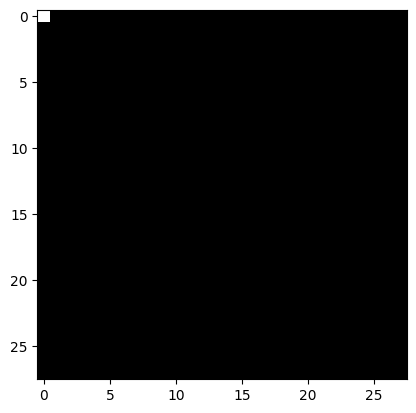

In [112]:
plt.imshow(np.real(np.outer(qs0,qs0.conj())),cmap='gray')

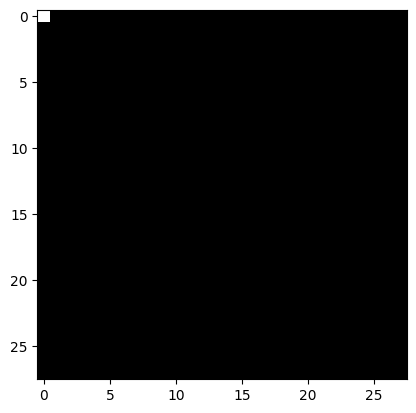

In [113]:
plt.imshow(np.real(np.outer(qu0,qu0.conj())),cmap='gray')

In [114]:
ls

array([ 4.38435567e+04,  2.80868398e+04,  2.27750494e+04,  1.56235830e+04,
        6.02458402e+03,  2.21198813e+03,  8.28704378e+02,  7.24180356e+02,
        4.62403074e+02,  2.73520301e+02,  1.43536173e+02,  4.03580916e+01,
        2.92850455e+01,  2.79747906e-03,  8.65747836e-12, -2.99436011e-12,
       -7.53307495e-13,  1.05332296e-12,  2.82277743e-13,  1.96474403e-13,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])

In [115]:
np.angle(lu)

array([ 2.65897974e+00,  1.61404524e+00,  1.00143762e+00, -2.93985216e+00,
       -2.13088107e+00, -2.55263876e+00, -2.69881948e+00, -1.49734835e+00,
        3.06898681e-01, -5.10357065e-01, -6.76082242e-01, -9.90690001e-01,
       -9.77089129e-01,  2.79747906e-03,  6.45439258e-12, -4.52328257e-12,
       -1.64068379e-12,  1.34932171e-12,  7.80242068e-13, -1.06546046e-13,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00])